# Morris Sensitivity Analysis – SnowToSwe (Mag25 dataset)

Functionally equivalent to `morris_SNOWPACK/morris_sensitivity.ipynb`.  
Data source replaced with the **Mag25 observational dataset** (SLF biweekly snow-course measurements).  
Station **Weisfluh_Joch (WEI2)** is excluded throughout.

Computes **Elementary Effect (Morris)** indices for all 7 ΔSnow parameters using
**SALib** (Herman & Usher, 2017; Iwanaga et al., 2022).  
Model input: daily HS from Mag25 stations (Sep 2016 – Aug 2022, 6 hydrological years).  
Output metric: mean NRMSE of modelled SWE vs observed SWE, evaluated **only on actual SWE observation dates** (biweekly, no interpolation).

| Parameter | Description | Lower | Default | Upper |
|-----------|-------------|------:|--------:|------:|
| `rho_max` | Maximum snow density [kg/m³] | 300 | 401.3 | 600 |
| `rho_null` | Fresh-snow density [kg/m³] | 50 | 81.2 | 200 |
| `c_ov` | Overburden compaction coefficient | 1e-6 | 5.1e-4 | 1e-3 |
| `k_ov` | Overburden density exponent | 0.01 | 0.38 | 10.0 |
| `k` | Viscosity density exponent | 0.01 | 0.030 | 0.2 |
| `tau` | New-snow threshold [m] | 0.01 | 0.024 | 0.2 |
| `eta_null` | Reference viscosity [Pa·s] | 1e6 | 8.5e6 | 2e7 |

Bounds from `calibration_SNOWPACK/dsnow_parameter_optimization_DE.R`.

## Schema differences: Mag25 vs SNOWPACK dataset

| Property | SNOWPACK (`alpsolut_all.nc`) | Mag25 (`Mag25_all.nc`) | Adaptation |
|----------|------------------------------|------------------------|------------|
| Time resolution | Hourly → resampled to daily | **Already daily** | Skip `resample()` |
| Dimension order | `(station, time)` | `(time, station)` | Transparent via `xr.sel(station=)` |
| Time range | Oct 2023 – Jul 2025 (2 partial years) | **Sep 2016 – Aug 2022 (6 complete years)** | `winter_years` updates automatically |
| Station count | 18 | 41 total, **40 after WEI2 exclusion**, 20 with SWE obs | Filter on load |
| SWE availability | Daily (model output) | **~biweekly field observations** (median gap 14–16 d) | Evaluate metric only on `~NaN` SWE dates |
| SWE units | mm | **mm** | No change |
| HS NaN fraction | ~5 % | **0 %** | `ffill` is a no-op but kept for consistency |
| `n_valid` threshold | 10 | **3** (biweekly → ~5–12 obs/winter, some stations sparse) | Lowered |
| Excluded station | — | **`Weisfluh_Joch`** (WEI2) | `drop_sel` on load |

All cells from § 2 onward (Morris sampling, model execution, analysis, plots) are **identical** to the SNOWPACK notebook.

In [1]:
import sys, os, io, contextlib, warnings
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path
from joblib import Parallel, delayed
from tqdm.auto import tqdm
from SALib.sample import morris as salib_sample
from SALib.analyze import morris as salib_analyze

# ── Project paths ─────────────────────────────────────────────────────────────
ROOT    = Path("/Users/jakobwerkgarner/code/mt_dsnow")
OUT_DIR = ROOT / "par_sens/morris_Mag25"
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "snow_to_swe_master"))

from main import SnowToSwe
from plot_style import apply_style, C, ALPHA, FIG

warnings.filterwarnings("ignore")
apply_style()

# ── Morris settings ────────────────────────────────────────────────────────────
N_TRAJ     = 50    # number of Morris trajectories (≥30 recommended)
NUM_LEVELS = 6     # grid discretisation levels (even number)
N_JOBS     = -1    # parallel workers (-1 = all cores; 1 = sequential)
SEED       = 42

# ── Parameter space (from DE calibration bounds) ───────────────────────────────
PARAM_NAMES  = ["rho_max", "rho_null", "c_ov", "k_ov", "k", "tau", "eta_null"]
PARAM_LATEX  = [r"$\rho_{max}$", r"$\rho_0$", r"$c_{ov}$",
                r"$k_{ov}$",     r"$k$",       r"$\tau$", r"$\eta_0$"]
PARAM_BOUNDS = [
    [300,  600  ],  # rho_max
    [50,   200  ],  # rho_null
    [1e-6, 1e-3 ],  # c_ov
    [0.01, 10.0 ],  # k_ov
    [0.01, 0.2  ],  # k
    [0.01, 0.2  ],  # tau
    [1e6,  2e7  ],  # eta_null
]
K = len(PARAM_NAMES)

# SALib problem definition — used for both sampling and analysis
PROBLEM = {
    'num_vars': K,
    'names':    PARAM_NAMES,
    'bounds':   PARAM_BOUNDS,
}

# One colour per parameter (Okabe-Ito palette via C.CYCLE)
PARAM_COLORS = dict(zip(PARAM_LATEX, C.CYCLE[:K]))

# ── Mag25-specific constants ───────────────────────────────────────────────────
EXCLUDE_STATION = "Weisfluh_Joch"   # WEI2 — excluded from all analysis
N_VALID_MIN     = 3                  # min SWE obs per block (biweekly → ~5–12/winter)

/Users/jakobwerkgarner/miniforge3/envs/MT_dsnow/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1 · Load data & build station×winter task list

In [2]:
DATA_PATH = ROOT / "calibration/calibration_data/raw_data/Mag25/SLF_dataset/Mag25_all.nc"

# ── Load — Mag25 is already daily, no resampling needed ───────────────────────
ds = xr.open_dataset(DATA_PATH)

# Exclude Weisfluh_Joch (WEI2) before any further processing
assert EXCLUDE_STATION in ds["station"].values, \
    f"Expected station '{EXCLUDE_STATION}' not found — check station names."
ds_daily = ds.drop_sel(station=EXCLUDE_STATION)

times_daily = pd.to_datetime(ds_daily["time"].values)

# Hydrological year: Sep 1 → Aug 31  (same convention as calibration scripts)
hyd_year_d   = np.where(times_daily.month >= 9, times_daily.year, times_daily.year - 1)
winter_years = np.unique(hyd_year_d)

# ── Build (station, winter) task list ─────────────────────────────────────────
# Mag25 dims are (time, station) — xr.sel(station=) returns a 1-D time series
# regardless of dim order, so the downstream code is identical to the SNOWPACK version.
station_names = ds_daily["station"].values
station_tasks = []   # list of (station_name, winter_year, hs_1d, swe_1d)

for stn in station_names:
    hs_full  = ds_daily["HS" ].sel(station=stn).values.astype(float)
    swe_full = ds_daily["SWE"].sel(station=stn).values.astype(float)

    for wy in winter_years:
        mask = hyd_year_d == wy
        # HS has no NaN in Mag25, but ffill is kept for consistency
        hs  = pd.Series(hs_full[mask]).ffill(limit=3).fillna(0).clip(lower=0).values
        swe = swe_full[mask]   # sparse — NaN on non-observation days

        # Valid SWE obs: actual field measurements (non-NaN, > 5 mm)
        # N_VALID_MIN=3 (not 10) because biweekly sampling yields only ~5–12 obs/winter
        n_valid = int(np.sum(~np.isnan(swe) & (swe > 5)))
        if n_valid < N_VALID_MIN or hs.max() < 0.05:
            continue

        # SnowToSwe requires hs[0] == 0 and hs[-1] == 0
        hs[0] = 0.0;  hs[-1] = 0.0

        station_tasks.append((stn, int(wy), hs, swe))

print(f"Stations total     : {len(ds['station'].values)}  (before exclusion)")
print(f"Excluded           : {EXCLUDE_STATION}")
print(f"Stations used      : {len(station_names)}")
print(f"Hydrological years : {list(winter_years)}")
print(f"Valid task blocks  : {len(station_tasks)}  (station × winter)")

Stations total     : 41  (before exclusion)
Excluded           : Weisfluh_Joch
Stations used      : 40
Hydrological years : [np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021)]
Valid task blocks  : 125  (station × winter)


In [3]:
# ── Validation checks ─────────────────────────────────────────────────────────

# 1. Confirm WEI2 exclusion
assert EXCLUDE_STATION not in station_names, "WEI2 exclusion failed!"
print(f"[OK] '{EXCLUDE_STATION}' excluded from all analysis.")

# 2. SWE observation summary per station
print("\nSWE observation counts per station (used tasks only):")
stn_swe_counts = {}
for stn, wy, hs, swe in station_tasks:
    n = int(np.sum(~np.isnan(swe) & (swe > 5)))
    stn_swe_counts.setdefault(stn, []).append(n)

for stn, counts in sorted(stn_swe_counts.items()):
    total   = sum(counts)
    n_yrs   = len(counts)
    print(f"  {stn:25s}  {n_yrs} winter(s)  {total:3d} obs total  "
          f"[{min(counts)}–{max(counts)} obs/winter]")

# 3. Check for irregular SWE sampling intervals
print("\nSWE sampling interval check (all stations):")
times_np = pd.to_datetime(ds_daily["time"].values)
irregular = []
for stn in station_names:
    swe_stn  = ds_daily["SWE"].sel(station=stn).values
    obs_idx  = np.where(~np.isnan(swe_stn))[0]
    if len(obs_idx) < 2:
        continue
    gaps     = np.diff(obs_idx)          # gaps in days (daily time axis)
    med_gap  = int(np.median(gaps))
    max_gap  = int(gaps.max())
    if max_gap > 60:
        irregular.append((stn, med_gap, max_gap))

if irregular:
    print("  Stations with gaps > 60 d (likely missing seasons):")
    for stn, med, mx in irregular:
        print(f"    {stn:25s}  median={med:3d} d  max={mx:3d} d  → NaN-masking handles this correctly")
else:
    print("  No station has a gap > 60 d.")

# 4. Time alignment spot-check
stn0, wy0, hs0, swe0 = station_tasks[0]
mask0    = hyd_year_d == wy0
n_days   = mask0.sum()
n_swe    = int(np.sum(~np.isnan(swe0) & (swe0 > 5)))
assert len(hs0) == n_days, "HS length mismatch — time alignment error!"
assert len(swe0) == n_days, "SWE length mismatch — time alignment error!"
print(f"\n[OK] Time alignment verified: {stn0} / {wy0}–{wy0+1}  "
      f"({n_days} daily steps, {n_swe} SWE obs used)")

[OK] 'Weisfluh_Joch' excluded from all analysis.

SWE observation counts per station (used tasks only):
  Adelboden                  5 winter(s)   29 obs total  [4–8 obs/winter]
  Bivio                      6 winter(s)   56 obs total  [5–15 obs/winter]
  Bourg_St_Pierre            5 winter(s)   29 obs total  [3–10 obs/winter]
  Braunwald                  6 winter(s)   52 obs total  [5–11 obs/winter]
  Davos_Flueelastr           6 winter(s)   50 obs total  [6–11 obs/winter]
  Fionnay                    6 winter(s)   57 obs total  [7–11 obs/winter]
  Gantrisch                  6 winter(s)   53 obs total  [6–10 obs/winter]
  Gsteig                     6 winter(s)   52 obs total  [6–10 obs/winter]
  Juf                        6 winter(s)   69 obs total  [9–15 obs/winter]
  Malbun                     6 winter(s)   45 obs total  [5–9 obs/winter]
  Maloja                     6 winter(s)   66 obs total  [10–12 obs/winter]
  Muenster                   6 winter(s)   41 obs total  [4–9 obs/winter

## 2 · Generate Morris sample (SALib)

In [4]:
# SALib generates N*(k+1) parameter sets arranged as N trajectories of k+1 points.
# optimal_trajectories=None uses the standard random design (Morris 1991).
X_flat = salib_sample.sample(
    PROBLEM,
    N          = N_TRAJ,
    num_levels = NUM_LEVELS,
    seed       = SEED,
)

print(f"Trajectories       : {N_TRAJ}")
print(f"Total model runs   : {len(X_flat)}  ({N_TRAJ} × {K+1})")  # N*(k+1) = 400

Trajectories       : 50
Total model runs   : 400  (50 × 8)


## 3 · Run Morris

In [5]:
def _nrmse_one_block(hs, swe_obs, params):
    """Run SnowToSwe on one (station, winter) block; returns NRMSE or NaN.

    For Mag25, swe_obs is sparse (biweekly field measurements).  The valid
    mask selects only actual observation dates — no interpolation is used.
    
    Returns NaN if the model fails or produces invalid output.
    """
    try:
        with contextlib.redirect_stdout(io.StringIO()):
            model    = SnowToSwe(**params)
            swe_pred = model.convert_list(hs.tolist(), timestep=24, verbose=False)
    except (IndexError, ValueError, TypeError, RuntimeError):
        # Model failed for this parameter set — skip it
        return np.nan
    
    if swe_pred is None:
        return np.nan

    swe_pred = np.asarray(swe_pred)
    
    # Validate output length matches input
    if len(swe_pred) != len(hs):
        return np.nan
    
    valid    = ~np.isnan(swe_obs) & (swe_obs > 5)   # actual observation dates only
    if valid.sum() < N_VALID_MIN:
        return np.nan

    rmse = np.sqrt(np.mean((swe_pred[valid] - swe_obs[valid]) ** 2))
    return float(rmse / swe_obs[valid].mean())


def evaluate_param_set(param_vec, tasks):
    """Mean NRMSE across all valid (station × winter) blocks for one param set."""
    import sys
    sys.path.insert(0, "/Users/jakobwerkgarner/code/mt_dsnow/snow_to_swe_master")

    params  = dict(zip(PARAM_NAMES, param_vec))
    nrmses  = [_nrmse_one_block(hs, swe, params) for _, _, hs, swe in tasks]
    valid   = [v for v in nrmses if not np.isnan(v)]
    return float(np.mean(valid)) if valid else np.nan


# ── Parallel execution ────────────────────────────────────────────────────────
Y_list = []
with tqdm(total=len(X_flat), desc="Morris runs", unit="param-set") as pbar:
    for y in Parallel(n_jobs=N_JOBS, return_as="generator")(
        delayed(evaluate_param_set)(x, station_tasks) for x in X_flat
    ):
        Y_list.append(y)
        pbar.update(1)

Y_flat = np.array(Y_list)

print(f"\nFinished. NaN results: {np.isnan(Y_flat).sum()} / {len(Y_flat)}")
print(f"NRMSE range: [{np.nanmin(Y_flat):.3f}, {np.nanmax(Y_flat):.3f}]")


Morris runs:  23%|██▎       | 93/400 [51:07<4:35:24, 53.82s/param-set] /Users/jakobwerkgarner/code/mt_dsnow/snow_to_swe_master/main.py:257: RuntimeWarning: overflow encountered in exp
  h_dd = x.iloc[0] / (1 + (x.iloc[2] * EARTH_GRAVITATIONAL_ACCELERATION * ts) / self.eta_null * exp(-self.k * x.iloc[1] / x.iloc[0]))
/Users/jakobwerkgarner/code/mt_dsnow/snow_to_swe_master/main.py:257: RuntimeWarning: overflow encountered in exp
  h_dd = x.iloc[0] / (1 + (x.iloc[2] * EARTH_GRAVITATIONAL_ACCELERATION * ts) / self.eta_null * exp(-self.k * x.iloc[1] / x.iloc[0]))
/Users/jakobwerkgarner/code/mt_dsnow/snow_to_swe_master/main.py:257: RuntimeWarning: overflow encountered in exp
  h_dd = x.iloc[0] / (1 + (x.iloc[2] * EARTH_GRAVITATIONAL_ACCELERATION * ts) / self.eta_null * exp(-self.k * x.iloc[1] / x.iloc[0]))
/Users/jakobwerkgarner/code/mt_dsnow/snow_to_swe_master/main.py:257: RuntimeWarning: overflow encountered in exp
  h_dd = x.iloc[0] / (1 + (x.iloc[2] * EARTH_GRAVITATIONAL_ACCELERATION * t


Finished. NaN results: 0 / 400
NRMSE range: [0.184, 0.937]


## 4 · Compute Morris indices (SALib)

In [11]:
# SALib returns a dict with keys: mu, mu_star, sigma, mu_star_conf
Si = salib_analyze.analyze(
    PROBLEM,
    X_flat,
    Y_flat,
    num_levels      = NUM_LEVELS,
    num_resamples   = 1000,   # bootstrap resamples for mu_star_conf
    print_to_console= False,
    seed            = SEED,
)

results = pd.DataFrame({
    "parameter"   : PARAM_LATEX,
    "name"        : PARAM_NAMES,
    "mu_star"     : Si["mu_star"],
    "mu_star_conf": Si["mu_star_conf"],   # 95 % bootstrap CI half-width
    "mu"          : Si["mu"],
    "sigma"       : Si["sigma"],
}).sort_values("mu_star", ascending=False).reset_index(drop=True)

display(results[["name", "mu_star", "mu_star_conf", "mu", "sigma"]]
        .rename(columns={"name": "parameter", "mu_star": "μ*",
                         "mu_star_conf": "μ* 95%-CI", "mu": "μ", "sigma": "σ"})
        .style.format({"μ*": "{:.4f}", "μ* 95%-CI": "±{:.4f}", "μ": "{:.4f}", "σ": "{:.4f}"})
        .background_gradient(subset="μ*", cmap="YlOrRd"))

,parameter,μ*,μ* 95%-CI,μ,σ
0,rho_null,0.3799,±0.0642,-0.1858,0.4059
1,tau,0.2232,±0.0321,0.1181,0.2248
2,rho_max,0.1981,±0.0657,0.1741,0.2533
3,k,0.1870,±0.0750,0.0426,0.3340
4,eta_null,0.0486,±0.0258,-0.0108,0.1053
5,k_ov,0.0342,±0.0125,-0.0078,0.0576
6,c_ov,0.0293,±0.0125,-0.0024,0.0539


In [12]:
# ── Save Morris outputs to disk ────────────────────────────────────────────────
np.save(OUT_DIR / "morris_X_flat_Mag25.npy", X_flat)
np.save(OUT_DIR / "morris_Y_flat_Mag25.npy", Y_flat)
results.to_csv(OUT_DIR / "morris_results_Mag25.csv", index=False)
print(f"Saved  X_flat  → {OUT_DIR / 'morris_X_flat_Mag25.npy'}")
print(f"Saved  Y_flat  → {OUT_DIR / 'morris_Y_flat_Mag25.npy'}")
print(f"Saved  results → {OUT_DIR / 'morris_results_Mag25.csv'}")

Saved  X_flat  → /Users/jakobwerkgarner/code/mt_dsnow/par_sens/morris_Mag25/morris_X_flat_Mag25.npy
Saved  Y_flat  → /Users/jakobwerkgarner/code/mt_dsnow/par_sens/morris_Mag25/morris_Y_flat_Mag25.npy
Saved  results → /Users/jakobwerkgarner/code/mt_dsnow/par_sens/morris_Mag25/morris_results_Mag25.csv


## 5 · Plots

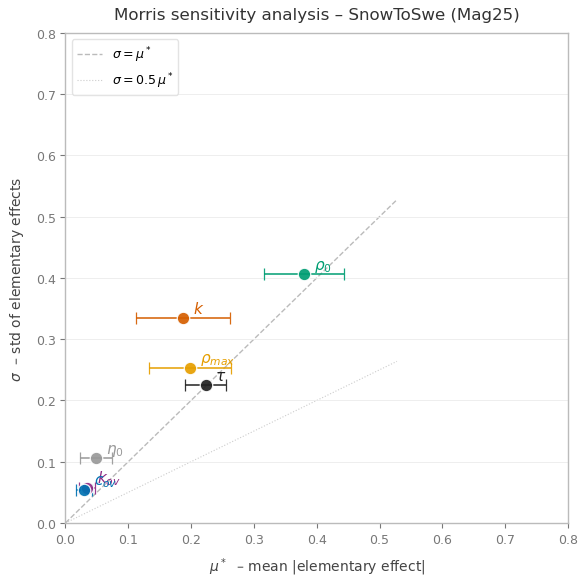

In [16]:
# ── Plot 1: μ* vs σ  (Morris chart) ──────────────────────────────────────────
#
# Parameters above the σ = μ* line have strong interactions / nonlinearity.
# Parameters near the origin are non-influential.

fig, ax = plt.subplots(figsize=(6,  6))

lim = max(results["mu_star"].max(), results["sigma"].max()) * 1.3
ax.plot([0, lim], [0, lim],       ls="--", lw=1.0, color="#BBBBBB", zorder=0, label=r"$\sigma = \mu^*$")
ax.plot([0, lim], [0, 0.5 * lim], ls=":",  lw=0.8, color="#CCCCCC", zorder=0, label=r"$\sigma = 0.5\,\mu^*$")

for _, row in results.iterrows():
    col = PARAM_COLORS[row["parameter"]]
    ax.errorbar(
        row["mu_star"], row["sigma"],
        xerr=row["mu_star_conf"],
        fmt="o", ms=9, color=col, ecolor=col, elinewidth=1.2,
        capsize=4, zorder=4, alpha=0.92,
        markeredgecolor="white", markeredgewidth=0.9,
    )
    ax.annotate(
        row["parameter"],
        xy=(row["mu_star"], row["sigma"]),
        xytext=(7, 4), textcoords="offset points",
        fontsize=11, color=col, fontweight="bold",
    )

ax.set_xlim(0, 0.8)
ax.set_ylim(0, 0.8)
ax.set_xlabel(r"$\mu^*$  – mean $|$elementary effect$|$", labelpad=7)
ax.set_ylabel(r"$\sigma$  – std of elementary effects",   labelpad=7)
ax.set_title("Morris sensitivity analysis – SnowToSwe (Mag25)", pad=10)
ax.legend(loc="upper left", fontsize=9, framealpha=0.8)

plt.tight_layout()
fig.savefig(OUT_DIR / "morris_scatter_Mag25.png", **FIG.SAVE)
plt.show()

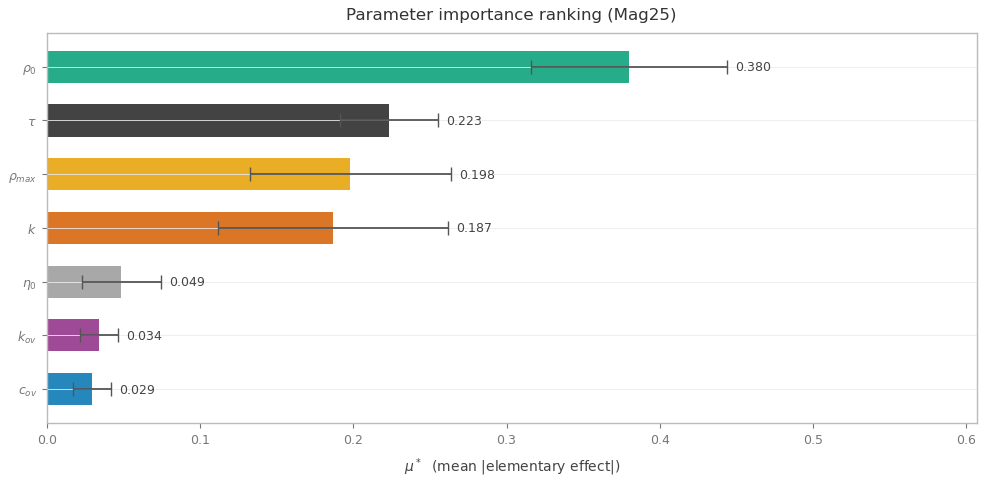

In [14]:
# ── Plot 2: μ* ranking bar chart ──────────────────────────────────────────────

ranked = results.sort_values("mu_star", ascending=True)   # ascending → most important on top

fig, ax = plt.subplots(figsize=FIG.SINGLE)

colors = [PARAM_COLORS[p] for p in ranked["parameter"]]
ax.barh(
    ranked["parameter"], ranked["mu_star"],
    xerr   = ranked["mu_star_conf"],
    color  = colors,
    height = 0.6,
    alpha  = 0.85,
    error_kw = dict(elinewidth=1.3, ecolor="#555555", capsize=5),
)

for _, row in ranked.iterrows():
    ax.text(row["mu_star"] + row["mu_star_conf"] + lim * 0.01,
            row["parameter"], f"{row['mu_star']:.3f}",
            va="center", fontsize=9, color="#444444")

ax.set_xlabel(r"$\mu^*$  (mean $|$elementary effect$|$)", labelpad=7)
ax.set_title("Parameter importance ranking (Mag25)", pad=10)
ax.set_xlim(0, lim * 1.15)

plt.tight_layout()
fig.savefig(OUT_DIR / "morris_ranking_Mag25.png", **FIG.SAVE)
plt.show()

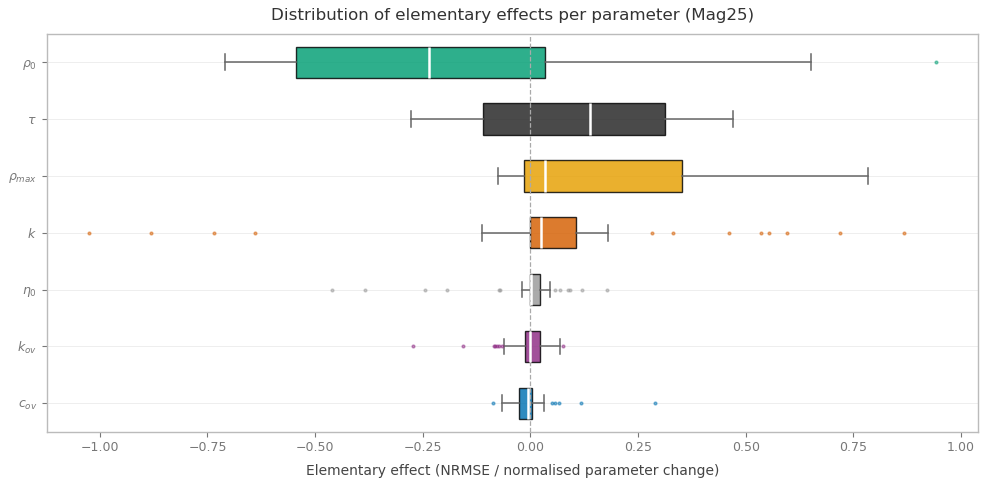

In [15]:
# ── Plot 3: EE distributions (box-plots per parameter) ───────────────────────
#
# SALib does not expose raw EEs, so we recompute them from the trajectory
# structure: consecutive points in each trajectory differ in exactly one
# parameter by one step Δ.  EE = ΔY / (Δx_j / range_j).

lo = np.array([b[0] for b in PARAM_BOUNDS])
hi = np.array([b[1] for b in PARAM_BOUNDS])

X_traj = X_flat.reshape(N_TRAJ, K + 1, K)   # (N, k+1, k)
Y_traj = Y_flat.reshape(N_TRAJ, K + 1)

EE_raw = [[] for _ in range(K)]
for r in range(N_TRAJ):
    for step in range(K):
        diff   = X_traj[r, step + 1] - X_traj[r, step]
        j      = int(np.argmax(np.abs(diff)))
        d_norm = diff[j] / (hi[j] - lo[j])
        if abs(d_norm) > 1e-12:
            EE_raw[j].append((Y_traj[r, step + 1] - Y_traj[r, step]) / d_norm)

order          = results.sort_values("mu_star", ascending=True).index.tolist()
labels_ordered = [results.loc[i, "parameter"] for i in order]
colors_ordered = [PARAM_COLORS[lbl] for lbl in labels_ordered]

name_to_idx = {n: i for i, n in enumerate(PARAM_NAMES)}
ee_data     = [EE_raw[name_to_idx[results.loc[i, "name"]]] for i in order]

fig, ax = plt.subplots(figsize=FIG.SINGLE)

bp = ax.boxplot(
    ee_data,
    vert        = False,
    labels      = labels_ordered,
    patch_artist= True,
    widths      = 0.55,
    flierprops  = dict(marker=".", markersize=4, alpha=0.5),
    medianprops = dict(color="white", linewidth=1.8),
)
for patch, col in zip(bp["boxes"], colors_ordered):
    patch.set_facecolor(col);  patch.set_alpha(0.82)
for whisker in bp["whiskers"] + bp["caps"]:
    whisker.set_color("#666666");  whisker.set_linewidth(1.1)
for flier, col in zip(bp["fliers"], colors_ordered):
    flier.set_markerfacecolor(col);  flier.set_markeredgecolor(col)

ax.axvline(0, color="#AAAAAA", lw=0.9, ls="--")
ax.set_xlabel("Elementary effect (NRMSE / normalised parameter change)", labelpad=7)
ax.set_title("Distribution of elementary effects per parameter (Mag25)", pad=10)

plt.tight_layout()
fig.savefig(OUT_DIR / "morris_ee_distributions_Mag25.png", **FIG.SAVE)
plt.show()